## **Setup**

In [22]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

WORKING_DIR = os.getcwd()

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = "/home/luigi/RecSys" if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

if IS_COLAB:
    !pip install optuna

Repo already exists — pulling latest changes
Already up to date.


In [23]:
if IS_COLAB or False:  # Set to True if you want to recompile Cython files
    os.chdir(LOCAL_REPO_PATH)
    !python run_compile_all_cython.py
    os.chdir(WORKING_DIR)

## **Imports**

In [24]:
import numpy as np
import scipy.sparse as sps
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from Challenge.paths import load_cv_folds, XGBOOST_MODELS
from Challenge.utils import load_models, evaluate_recommender, evaluate_recommender_implicit

## **Load Data**

In [25]:
folds = load_cv_folds(5)

## **Load all Models**

In [26]:
from Recommenders.NonPersonalizedRecommender import TopPop
from Recommenders.KNN.UserKNNCFRecommender import UserKNNCFRecommender
from Recommenders.KNN.ItemKNNCFRecommender import ItemKNNCFRecommender
from Recommenders.GraphBased.P3alphaRecommender import P3alphaRecommender
from Recommenders.GraphBased.RP3betaRecommender import RP3betaRecommender
from Recommenders.EASE_R.EASE_R_Recommender import EASE_R_Recommender
from Recommenders.SLIM.SLIMElasticNetRecommender import MultiThreadSLIM_SLIMElasticNetRecommender
from Recommenders.MatrixFactorization.Cython.MatrixFactorization_Cython import MatrixFactorization_WARP_Cython
from Recommenders.MatrixFactorization.Cython.MatrixFactorization_Cython import MatrixFactorization_BPR_Cython
from Recommenders.MatrixFactorization.Cython.MatrixFactorization_Cython import MatrixFactorization_SVDpp_Cython

from Recommenders.SLIM.Cython.SLIM_BPR_Cython import SLIM_BPR_Cython
from implicit.cpu.als import AlternatingLeastSquares
from Recommenders.MatrixFactorization.NMFRecommender import NMFRecommender
from Recommenders.Neural.MultVAE_PyTorch_Recommender import MultVAERecommender_PyTorch_OptimizerMask

In [27]:
models_mapping = {
    'TopPop': TopPop,
    'ItemKNN_cosine': ItemKNNCFRecommender,
    'ItemKNN_jaccard': ItemKNNCFRecommender,
    'ItemKNN_asymmetric': ItemKNNCFRecommender,
    'ItemKNN_tversky': ItemKNNCFRecommender,
    'ItemKNN_dice': ItemKNNCFRecommender,
    'UserKNN_cosine': UserKNNCFRecommender,
    'UserKNN_jaccard': UserKNNCFRecommender,
    'UserKNN_asymmetric': UserKNNCFRecommender,
    'UserKNN_tversky': UserKNNCFRecommender,
    'UserKNN_dice': UserKNNCFRecommender,
    'EASE_R': EASE_R_Recommender,
    'P3alpha': P3alphaRecommender,
    'RP3beta': RP3betaRecommender,
    'IALS': AlternatingLeastSquares,
    'MatrixFactorization_WARP': MatrixFactorization_WARP_Cython,
    'MatrixFactorization_BPR': MatrixFactorization_BPR_Cython,
    # 'MatrixFactorization_SVDpp': MatrixFactorization_SVDpp_Cython,
    
    # 'SLIM_BPR': SLIM_BPR_Cython,
    'NMF': NMFRecommender,
    'MultVAE': MultVAERecommender_PyTorch_OptimizerMask,
    'SLIMElasticNet': MultiThreadSLIM_SLIMElasticNetRecommender
}

In [28]:
folder = os.path.join(XGBOOST_MODELS, "train_features")
outer_folder = os.path.join(folder, "outer_folds")

## **Candidate Selection - Greedy Gain/Cost**

In [29]:
def get_user_batches(user_ids, batch_size=1000):
    for i in range(0, len(user_ids), batch_size):
        yield user_ids[i:i + batch_size]

In [30]:
def precumpute_recommendations(URM_train, user_ids, models_mapping, folder, max_cutoff):
    model_recs_cache = {}
    model_names = []
    for model_name, model in load_models(URM_train, models_mapping, folder, verbose=False):
        print(f"Precomputing recommendations for {model_name}...")
        model_names.append(model_name)

        if type(model) == AlternatingLeastSquares:
            recommended_items, scores = model.recommend(
                user_ids, 
                URM_train, 
                N=max_cutoff, 
                filter_already_liked_items=True
            )

        elif type(model) == MultVAERecommender_PyTorch_OptimizerMask:
            # Do in batches to avoid OOM in GPU
            recommended_items = []
            for user_batch in get_user_batches(user_ids, batch_size=500):
                batch_recs = model.recommend(user_batch, cutoff=max_cutoff)
                recommended_items.extend(batch_recs)
            recommended_items = recommended_items

        else:
            recommended_items = model.recommend(user_ids, cutoff=max_cutoff)

        model_recs_cache[model_name] = np.array(recommended_items)

    return model_recs_cache, model_names

In [31]:
def greedy_candidate_selection(URM_train, URM_val, model_names, model_recs_cache, cutoffs, budget):
    n_users, n_items = URM_train.shape
    current_candidates_mask = sps.csr_matrix((n_users, n_items), dtype=bool)

    URM_val_bool = URM_val.astype(bool)

    selected_cutoffs = {name: 0 for name in model_names}
    avg_candidate_count = 0
    total_gain = 0

    # Visualization history
    history_candidates = [0]
    history_recall = [0]
    history_ratios = []

    while avg_candidate_count < budget:
        best_cutoff_config = None
        best_ratio = -1
        best_gain = 0
        best_cost = 0

        # Iterate through pre-loaded models
        for model_name in model_names:
            current_cutoff = selected_cutoffs[model_name]
            
            # Get all possible future cutoffs
            future_cutoffs = [c for c in cutoffs if c > current_cutoff]

            # OPTIMIZATION: Only look at the next 3 steps.
            # If we are at 10, check [20, 30, 40]. 
            # We don't need to calculate cost/gain for 500 yet.
            # It is unlikely that skipping directly to very high cutoffs is optimal.
            search_horizon = future_cutoffs[:3]

            # Check potential next cutoffs
            for next_cutoff in search_horizon:
                if next_cutoff <= current_cutoff:
                    continue

                # --- VECTORIZED CHECK ---
                new_recs_slice = model_recs_cache[model_name][:, current_cutoff:next_cutoff]

                # Flatten the slice to create sparse matrix coordinates
                rows = np.repeat(np.arange(n_users), new_recs_slice.shape[1])
                cols = new_recs_slice.flatten()

                # Filter out items that are ALREADY selected
                data = np.ones(len(cols), dtype=bool)
                proposal_matrix = sps.csr_matrix((data, (rows, cols)), shape=(n_users, n_items))

                # "greater than" acts as set difference: (Proposal > Current)
                # If Proposal has 1 and Current has 1, result is False (already exists)
                # If Proposal has 1 and Current has 0, result is True (new item)
                # We use > instead of != to avoid 0 != 1 cases where we don't care
                new_items_mask = (proposal_matrix > current_candidates_mask)

                marginal_cost = new_items_mask.nnz

                if marginal_cost == 0:
                    continue

                # Calculate Gain (Intersection with Validation)
                # Element-wise multiplication (AND operation)
                hits_mask = new_items_mask.multiply(URM_val_bool)
                marginal_gain = hits_mask.nnz

                ratio = marginal_gain / marginal_cost

                # Maximize Ratio
                if ratio > best_ratio:
                    best_ratio = ratio
                    best_cutoff_config = (model_name, next_cutoff)
                    best_gain = marginal_gain
                    best_cost = marginal_cost
                    # Store the mask to avoid re-computing it in the update step
                    best_proposal_mask = new_items_mask

        if best_cutoff_config is None:
            print("No more positive movements possible.")
            break

        # Add the best found configuration
        best_model, best_step = best_cutoff_config
        selected_cutoffs[best_model] = best_step
        
        # Update global candidates with the pre-calculated mask
        # Logical OR update
        current_candidates_mask = current_candidates_mask + best_proposal_mask

        # Calculate new average
        total_candidates = current_candidates_mask.nnz
        avg_candidate_count = total_candidates / n_users

        # Update total gain and current recall
        total_gain += best_gain
        current_recall = total_gain / URM_val.getnnz()

        # Update history for plotting
        history_candidates.append(avg_candidate_count)
        history_recall.append(current_recall)
        history_ratios.append(best_ratio)

        print(f"Selected {best_model} @ {best_step}. "
            f"Ratio: {best_ratio:.5f}. "
            f"Cost: {best_cost}. "
            f"Avg Candidates: {avg_candidate_count:.2f}. "
            f"RECALL: {current_recall:.4f}")

    print("---------------------------------------------------")
    print("Final Selection:", selected_cutoffs)

    return selected_cutoffs, history_candidates, history_recall, history_ratios

In [32]:
def plot_cv_history(cv_histories, max_budget=300):
    fig, ax1 = plt.subplots(figsize=(12, 7))
    
    # 1. Define a common X-axis for interpolation (e.g., 0 to 300 in 100 steps)
    common_x = np.linspace(0, max_budget, 100)
    
    interp_recalls = []
    interp_ratios = []
    
    # Colors
    color_recall = 'tab:blue'
    color_ratio = 'tab:red'
    
    # 2. Process each split
    for i, history in enumerate(cv_histories):
        # Unpack data
        x = history['candidates']
        y_rec = history['recall']
        y_rat = [0] + history['ratios'] # Pad ratio with 0 for index 0 to match length
        
        # Ensure x is strictly increasing for interpolation (remove duplicates if any)
        # Usually not needed but good safety
        _, unique_indices = np.unique(x, return_index=True)
        x = np.array(x)[unique_indices]
        y_rec = np.array(y_rec)[unique_indices]
        y_rat = np.array(y_rat)[unique_indices]

        # Interpolate to common grid
        f_rec = interp1d(x, y_rec, kind='linear', bounds_error=False, fill_value="extrapolate")
        f_rat = interp1d(x, y_rat, kind='linear', bounds_error=False, fill_value=0)
        
        interp_recalls.append(f_rec(common_x))
        interp_ratios.append(f_rat(common_x))
        
        # Plot individual faint lines (Spaghetti plot)
        ax1.plot(x, y_rec, color=color_recall, alpha=0.15, linewidth=1)

    # 3. Calculate Mean and Std Dev
    mean_recall = np.mean(interp_recalls, axis=0)
    std_recall = np.std(interp_recalls, axis=0)
    
    mean_ratio = np.mean(interp_ratios, axis=0)

    # 4. Plot Mean Recall (Bold)
    ax1.plot(common_x, mean_recall, color=color_recall, linewidth=3, label='Mean Recall')
    
    # Plot Standard Deviation (Shaded Area) - Shows Stability
    ax1.fill_between(common_x, 
                     mean_recall - std_recall, 
                     mean_recall + std_recall, 
                     color=color_recall, alpha=0.2, label='Recall Std Dev')

    ax1.set_xlabel('Average Candidates per User')
    ax1.set_ylabel('Recall', color=color_recall, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_recall)
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax1.set_ylim(bottom=0)

    # 5. Plot Mean Ratio (Secondary Axis)
    ax2 = ax1.twinx()
    ax2.plot(common_x, mean_ratio, color=color_ratio, linestyle='--', linewidth=2, label='Mean Marginal Ratio')
    ax2.set_ylabel('Marginal Ratio (Gain/Cost)', color=color_ratio, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_ratio)
    
    # Start Ratio from 0 to avoid huge spikes distorting the view
    ax2.set_ylim(bottom=0, top=np.max(mean_ratio)*1.2)

    plt.title(f'Candidate Selection Stability ({len(cv_histories)} Folds)')
    
    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
    
    plt.show()

In [12]:
budget = 300
cutoffs = [
    5, 10, 15, 20, 25, 30, 40, 50,    # High precision area
    60, 70, 80, 90, 100,              # Mid range
    120, 140, 160, 180, 200,          # Extended range
    250, 300                          # Deep candidates
]
max_cutoff = max(cutoffs)

selected_cutoffs_all_folds = []
cv_histories = []

for fold_index, (URM_train, URM_val) in enumerate(folds):
    print(f"Processing Fold {fold_index}...")
    
    # Pre-compute recommendations for all models
    user_ids = np.arange(URM_train.shape[0])
    model_recs_cache, model_names = precumpute_recommendations(
        URM_train, 
        user_ids, 
        models_mapping, 
        os.path.join(outer_folder, f"fold_{fold_index}"),
        max_cutoff
    )

    # Perform greedy candidate selection
    selected_cutoffs, history_candidates, history_recall, history_ratios = greedy_candidate_selection(
        URM_train, 
        URM_val, 
        model_names, 
        model_recs_cache, 
        cutoffs, 
        budget
    )

    # Store results
    selected_cutoffs_all_folds.append(selected_cutoffs)
    cv_histories.append({
        'candidates': history_candidates,
        'recall': history_recall,
        'ratios': history_ratios
    })

Processing Fold 0...
TopPopRecommender: Loading model from file '/home/luigi/RecSys/xg_boost_data/models/train_features/outer_folds/fold_0TopPop'
TopPopRecommender: Loading complete
Precomputing recommendations for TopPop...
ItemKNNCFRecommender: Loading model from file '/home/luigi/RecSys/xg_boost_data/models/train_features/outer_folds/fold_0ItemKNN_cosine'
ItemKNNCFRecommender: Loading complete
Precomputing recommendations for ItemKNN_cosine...
ItemKNNCFRecommender: Loading model from file '/home/luigi/RecSys/xg_boost_data/models/train_features/outer_folds/fold_0ItemKNN_jaccard'
ItemKNNCFRecommender: Loading complete
Precomputing recommendations for ItemKNN_jaccard...
ItemKNNCFRecommender: Loading model from file '/home/luigi/RecSys/xg_boost_data/models/train_features/outer_folds/fold_0ItemKNN_asymmetric'
ItemKNNCFRecommender: Loading complete
Precomputing recommendations for ItemKNN_asymmetric...
ItemKNNCFRecommender: Loading model from file '/home/luigi/RecSys/xg_boost_data/models/

/home/luigi/.venvs/recsys/lib/python3.13/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 12 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


Precomputing recommendations for IALS...
MatrixFactorization_WARP_Cython_Recommender: Loading model from file '/home/luigi/RecSys/xg_boost_data/models/train_features/outer_folds/fold_0MatrixFactorization_WARP'
MatrixFactorization_WARP_Cython_Recommender: Loading complete
Precomputing recommendations for MatrixFactorization_WARP...
MatrixFactorization_BPR_Cython_Recommender: Loading model from file '/home/luigi/RecSys/xg_boost_data/models/train_features/outer_folds/fold_0MatrixFactorization_BPR'
MatrixFactorization_BPR_Cython_Recommender: Loading complete
Precomputing recommendations for MatrixFactorization_BPR...
NMFRecommender: Loading model from file '/home/luigi/RecSys/xg_boost_data/models/train_features/outer_folds/fold_0NMF'
NMFRecommender: Loading complete
Precomputing recommendations for NMF...
Precomputing recommendations for MultVAE...


/home/luigi/RecSys/Recommenders/Neural/MultVAE_PyTorch_Recommender.py:203: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  user_batch_tensor = torch.sparse_csr_tensor(


SLIMElasticNetRecommender: Loading model from file '/home/luigi/RecSys/xg_boost_data/models/train_features/outer_folds/fold_0SLIMElasticNet'
SLIMElasticNetRecommender: Loading complete
Precomputing recommendations for SLIMElasticNet...
Selected SLIMElasticNet @ 5. Ratio: 0.30228. Cost: 135475. Avg Candidates: 5.00. RECALL: 0.0673
Selected EASE_R @ 5. Ratio: 0.25479. Cost: 31948. Avg Candidates: 6.18. RECALL: 0.0807
Selected SLIMElasticNet @ 10. Ratio: 0.22982. Cost: 109977. Avg Candidates: 10.24. RECALL: 0.1222
Selected MultVAE @ 5. Ratio: 0.20542. Cost: 51661. Avg Candidates: 12.14. RECALL: 0.1396
Selected RP3beta @ 5. Ratio: 0.20468. Cost: 35924. Avg Candidates: 13.47. RECALL: 0.1517
Selected EASE_R @ 10. Ratio: 0.19176. Cost: 36103. Avg Candidates: 14.80. RECALL: 0.1631
Selected SLIMElasticNet @ 15. Ratio: 0.18628. Cost: 84774. Avg Candidates: 17.93. RECALL: 0.1890
Selected ItemKNN_asymmetric @ 5. Ratio: 0.16667. Cost: 17520. Avg Candidates: 18.58. RECALL: 0.1938
Selected IALS @ 5. 

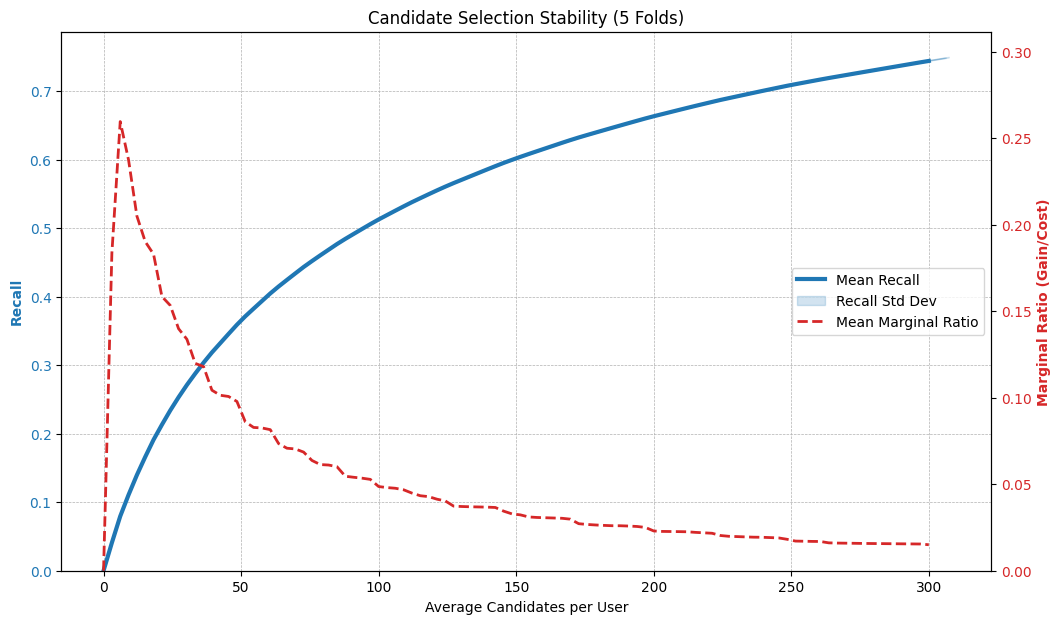

In [13]:
plot_cv_history(cv_histories, max_budget=300)

In [9]:
folds_selection = [
    {'TopPop': 0, 'ItemKNN_cosine': 25, 'ItemKNN_jaccard': 25, 'ItemKNN_asymmetric': 10, 'ItemKNN_tversky': 10, 'ItemKNN_dice': 30, 'UserKNN_cosine': 20, 'UserKNN_jaccard': 30, 'UserKNN_asymmetric': 25, 'UserKNN_tversky': 80, 'UserKNN_dice': 70, 'EASE_R': 60, 'P3alpha': 5, 'RP3beta': 5, 'IALS': 70, 'MatrixFactorization_WARP': 60, 'MatrixFactorization_BPR': 0, 'NMF': 0, 'MultVAE': 200, 'SLIMElasticNet': 250},
    {'TopPop': 0, 'ItemKNN_cosine': 40, 'ItemKNN_jaccard': 15, 'ItemKNN_asymmetric': 10, 'ItemKNN_tversky': 10, 'ItemKNN_dice': 20, 'UserKNN_cosine': 20, 'UserKNN_jaccard': 0, 'UserKNN_asymmetric': 10, 'UserKNN_tversky': 80, 'UserKNN_dice': 60, 'EASE_R': 80, 'P3alpha': 10, 'RP3beta': 5, 'IALS': 80, 'MatrixFactorization_WARP': 60, 'MatrixFactorization_BPR': 0, 'NMF': 0, 'MultVAE': 200, 'SLIMElasticNet': 250},
    {'TopPop': 10, 'ItemKNN_cosine': 30, 'ItemKNN_jaccard': 30, 'ItemKNN_asymmetric': 10, 'ItemKNN_tversky': 10, 'ItemKNN_dice': 15, 'UserKNN_cosine': 15, 'UserKNN_jaccard': 10, 'UserKNN_asymmetric': 10, 'UserKNN_tversky': 60, 'UserKNN_dice': 60, 'EASE_R': 70, 'P3alpha': 5, 'RP3beta': 5, 'IALS': 80, 'MatrixFactorization_WARP': 60, 'MatrixFactorization_BPR': 0, 'NMF': 0, 'MultVAE': 200, 'SLIMElasticNet': 250},
    {'TopPop': 0, 'ItemKNN_cosine': 25, 'ItemKNN_jaccard': 30, 'ItemKNN_asymmetric': 5, 'ItemKNN_tversky': 10, 'ItemKNN_dice': 25, 'UserKNN_cosine': 20, 'UserKNN_jaccard': 25, 'UserKNN_asymmetric': 40, 'UserKNN_tversky': 80, 'UserKNN_dice': 70, 'EASE_R': 60, 'P3alpha': 10, 'RP3beta': 5, 'IALS': 80, 'MatrixFactorization_WARP': 60, 'MatrixFactorization_BPR': 0, 'NMF': 0, 'MultVAE': 200, 'SLIMElasticNet': 250},
    {'TopPop': 0, 'ItemKNN_cosine': 30, 'ItemKNN_jaccard': 20, 'ItemKNN_asymmetric': 10, 'ItemKNN_tversky': 15, 'ItemKNN_dice': 20, 'UserKNN_cosine': 15, 'UserKNN_jaccard': 0, 'UserKNN_asymmetric': 40, 'UserKNN_tversky': 70, 'UserKNN_dice': 80, 'EASE_R': 70, 'P3alpha': 5, 'RP3beta': 5, 'IALS': 80, 'MatrixFactorization_WARP': 40, 'MatrixFactorization_BPR': 0, 'NMF': 5, 'MultVAE': 200, 'SLIMElasticNet': 250}
]

In [10]:
avg_selection = {}
for model_name in models_mapping.keys():
    total = sum(fold_selection.get(model_name, 0) for fold_selection in folds_selection)
    avg_selection[model_name] = total // len(folds_selection)

avg_selection

{'TopPop': 2,
 'ItemKNN_cosine': 30,
 'ItemKNN_jaccard': 24,
 'ItemKNN_asymmetric': 9,
 'ItemKNN_tversky': 11,
 'ItemKNN_dice': 22,
 'UserKNN_cosine': 18,
 'UserKNN_jaccard': 13,
 'UserKNN_asymmetric': 25,
 'UserKNN_tversky': 74,
 'UserKNN_dice': 68,
 'EASE_R': 68,
 'P3alpha': 7,
 'RP3beta': 5,
 'IALS': 78,
 'MatrixFactorization_WARP': 56,
 'MatrixFactorization_BPR': 0,
 'NMF': 1,
 'MultVAE': 200,
 'SLIMElasticNet': 250}

In [ ]:
# Based on average selection and stability, finalize the candidate selection

final_selection = {
    # --- The Heavy Lifters (Keep Maxed) ---
    'SLIMElasticNet': 250,   # Rock solid. Always 250.
    'MultVAE': 200,          # Rock solid. Always 200.
    'IALS': 80,              # Round 78 -> 80
    'EASE_R': 70,            # Average of 68 -> 70
    'UserKNN_tversky': 75,   # Average 74 -> 75
    'UserKNN_dice': 70,      # Average 68 -> 70
    'MatrixFactorization_WARP': 55, # Average 56 -> 55

    # --- The Support (Mid Range) ---
    'ItemKNN_cosine': 30,
    'ItemKNN_jaccard': 25,
    'ItemKNN_dice': 25,      # Round 22 -> 25
    'UserKNN_asymmetric': 25,
    'UserKNN_cosine': 20,    # Round 18 -> 20

    # --- The Minor Corrections (Low Range) ---
    'UserKNN_jaccard': 15,   # Keep it small due to instability
    'ItemKNN_tversky': 10,
    'ItemKNN_asymmetric': 10,
    'P3alpha': 5,            # Keep as filler
    'RP3beta': 5,            # Keep as filler

    # --- The Noise (DROP) ---
    'TopPop': 0,             # Drop (Avg 2)
    'NMF': 0,                # Drop (Avg 1)
    'MatrixFactorization_BPR': 0
}

In [33]:
# Convert your dictionary to a list for sorting
final_selection = {
    'SLIMElasticNet': 250,
    'MultVAE': 200, 
    'IALS': 80,
    'EASE_R': 70,
    'UserKNN_tversky': 75,
    'UserKNN_dice': 70, 
    'MatrixFactorization_WARP': 55,
    'ItemKNN_cosine': 30,
    'ItemKNN_jaccard': 25,
    'ItemKNN_dice': 25,
    'UserKNN_asymmetric': 25,
    'UserKNN_cosine': 20,
    'UserKNN_jaccard': 15,
    'ItemKNN_tversky': 10,
    'ItemKNN_asymmetric': 10,
    'P3alpha': 5,
    'RP3beta': 5
}

# remove models with 0 cutoff
candidate_mapping = {name: model_class for name, model_class in models_mapping.items() if final_selection.get(name, 0) > 0}


In [34]:
for fold_index, (URM_train, URM_val) in enumerate(folds):
    print(f"Processing Fold {fold_index}...")
    
    # Pre-compute recommendations for all models
    user_ids = np.arange(URM_train.shape[0])
    model_recs_cache, model_names = precumpute_recommendations(
        URM_train, 
        user_ids, 
        candidate_mapping, 
        os.path.join(outer_folder, f"fold_{fold_index}"),
        250 # SLIMElasticNet max cutoff
    )

    # Load Ground Truth as boolean for fast check
    URM_val_bool = URM_val.astype(bool)
    n_users, n_items = URM_train.shape

    # This mask tracks "What we have already found"
    current_union_mask = sps.csr_matrix((n_users, n_items), dtype=bool)

    # We will store the results here
    marginal_contributions = []

    # 2. ITERATIVE SELECTION
    # We loop until no models are left, picking the best one each time
    remaining_models = list(final_selection.keys())

    print(f"{'Model':<30} | {'Cutoff':<6} | {'New Hits':<8} | {'Cumul Recall':<12}")
    print("-" * 65)

    cumulative_hits = 0
    total_possible_hits = URM_val.nnz

    while remaining_models:
        best_model = None
        best_new_hits = -1
        best_model_mask = None
        
        # Check every remaining model against the CURRENT union
        for model_name in remaining_models:
            cutoff = final_selection[model_name]
            
            # Get the recommendations for this specific cutoff
            # (Assuming model_recs_cache is available as numpy array)
            recs = model_recs_cache[model_name][:, :cutoff]
            
            # Create Sparse Matrix of these recs
            rows = np.repeat(np.arange(n_users), recs.shape[1])
            cols = recs.flatten()
            data = np.ones(len(cols), dtype=bool)
            model_mask = sps.csr_matrix((data, (rows, cols)), shape=(n_users, n_items))
            
            # CRITICAL STEP: Find NEW items
            # Logic: (Model has it) AND (Current Union does NOT have it)
            # In sparse boolean: model_mask > current_union_mask
            new_items_mask = model_mask > current_union_mask
            
            # Check how many of these NEW items are Relevant (Hits)
            new_hits_mask = new_items_mask.multiply(URM_val_bool)
            new_hits_count = new_hits_mask.nnz
            
            if new_hits_count > best_new_hits:
                best_new_hits = new_hits_count
                best_model = model_name
                best_model_mask = model_mask # Save the full mask of the best model
                
        # 3. UPDATE THE UNION
        if best_model is None or best_new_hits <= 0:
            # Stop if no remaining model adds even 1 hit
            break
            
        cumulative_hits += best_new_hits
        recall = cumulative_hits / total_possible_hits
        
        print(f"{best_model:<30} | {final_selection[best_model]:<6} | {best_new_hits:<8} | {recall:.5f}")
        
        # Add the best model's items to the union
        # Logic: Union = Union OR Best_Model
        current_union_mask = current_union_mask + best_model_mask
        
        # Remove from list
        remaining_models.remove(best_model)
        
    print("-" * 65)
    print("Remaining models (redundant):", remaining_models)

Processing Fold 0...
ItemKNNCFRecommender: Loading model from file '/home/luigi/RecSys/xg_boost_data/models/train_features/outer_folds/fold_0ItemKNN_cosine'
ItemKNNCFRecommender: Loading complete
Precomputing recommendations for ItemKNN_cosine...
ItemKNNCFRecommender: Loading model from file '/home/luigi/RecSys/xg_boost_data/models/train_features/outer_folds/fold_0ItemKNN_jaccard'
ItemKNNCFRecommender: Loading complete
Precomputing recommendations for ItemKNN_jaccard...
ItemKNNCFRecommender: Loading model from file '/home/luigi/RecSys/xg_boost_data/models/train_features/outer_folds/fold_0ItemKNN_asymmetric'
ItemKNNCFRecommender: Loading complete
Precomputing recommendations for ItemKNN_asymmetric...
ItemKNNCFRecommender: Loading model from file '/home/luigi/RecSys/xg_boost_data/models/train_features/outer_folds/fold_0ItemKNN_tversky'
ItemKNNCFRecommender: Loading complete
Precomputing recommendations for ItemKNN_tversky...
ItemKNNCFRecommender: Loading model from file '/home/luigi/RecS

/home/luigi/.venvs/recsys/lib/python3.13/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 12 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


Precomputing recommendations for IALS...
MatrixFactorization_WARP_Cython_Recommender: Loading model from file '/home/luigi/RecSys/xg_boost_data/models/train_features/outer_folds/fold_0MatrixFactorization_WARP'
MatrixFactorization_WARP_Cython_Recommender: Loading complete
Precomputing recommendations for MatrixFactorization_WARP...
Precomputing recommendations for MultVAE...


/home/luigi/RecSys/Recommenders/Neural/MultVAE_PyTorch_Recommender.py:203: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  user_batch_tensor = torch.sparse_csr_tensor(


SLIMElasticNetRecommender: Loading model from file '/home/luigi/RecSys/xg_boost_data/models/train_features/outer_folds/fold_0SLIMElasticNet'
SLIMElasticNetRecommender: Loading complete
Precomputing recommendations for SLIMElasticNet...
Model                          | Cutoff | New Hits | Cumul Recall
-----------------------------------------------------------------
SLIMElasticNet                 | 250    | 421532   | 0.69261
MultVAE                        | 200    | 28737    | 0.73983
IALS                           | 80     | 1931     | 0.74300
UserKNN_tversky                | 75     | 1726     | 0.74584
MatrixFactorization_WARP       | 55     | 707      | 0.74700
UserKNN_dice                   | 70     | 421      | 0.74769
ItemKNN_jaccard                | 25     | 66       | 0.74780
EASE_R                         | 70     | 56       | 0.74789
ItemKNN_cosine                 | 30     | 42       | 0.74796
ItemKNN_dice                   | 25     | 25       | 0.74800
ItemKNN_asymmetric    

- Fold 1
Model                          | Cutoff | New Hits | Cumul Recall
-----------------------------------------------------------------
SLIMElasticNet                 | 250    | 421532   | 0.69261
MultVAE                        | 200    | 28737    | 0.73983
IALS                           | 80     | 1931     | 0.74300
UserKNN_tversky                | 75     | 1726     | 0.74584
MatrixFactorization_WARP       | 55     | 707      | 0.74700
UserKNN_dice                   | 70     | 421      | 0.74769
ItemKNN_jaccard                | 25     | 66       | 0.74780
EASE_R                         | 70     | 56       | 0.74789
ItemKNN_cosine                 | 30     | 42       | 0.74796
ItemKNN_dice                   | 25     | 25       | 0.74800
ItemKNN_asymmetric             | 10     | 23       | 0.74804
UserKNN_asymmetric             | 25     | 8        | 0.74805
P3alpha                        | 5      | 4        | 0.74806
RP3beta                        | 5      | 2        | 0.74806
UserKNN_cosine                 | 20     | 1        | 0.74806
-----------------------------------------------------------------
Remaining models (redundant): ['UserKNN_jaccard', 'ItemKNN_tversky']

- Fold 2
Model                          | Cutoff | New Hits | Cumul Recall
-----------------------------------------------------------------
SLIMElasticNet                 | 250    | 422253   | 0.69380
MultVAE                        | 200    | 28523    | 0.74066
IALS                           | 80     | 1980     | 0.74392
UserKNN_tversky                | 75     | 1698     | 0.74671
MatrixFactorization_WARP       | 55     | 730      | 0.74791
UserKNN_dice                   | 70     | 362      | 0.74850
EASE_R                         | 70     | 61       | 0.74860
ItemKNN_dice                   | 25     | 51       | 0.74868
ItemKNN_asymmetric             | 10     | 28       | 0.74873
ItemKNN_cosine                 | 30     | 26       | 0.74877
ItemKNN_jaccard                | 25     | 16       | 0.74880
UserKNN_asymmetric             | 25     | 8        | 0.74881
RP3beta                        | 5      | 5        | 0.74882
P3alpha                        | 5      | 2        | 0.74882
UserKNN_cosine                 | 20     | 1        | 0.74883
ItemKNN_tversky                | 10     | 1        | 0.74883
-----------------------------------------------------------------
Remaining models (redundant): ['UserKNN_jaccard']

- Fold 3
Model                          | Cutoff | New Hits | Cumul Recall
-----------------------------------------------------------------
SLIMElasticNet                 | 250    | 421608   | 0.69274
MultVAE                        | 200    | 29092    | 0.74054
IALS                           | 80     | 1898     | 0.74366
UserKNN_tversky                | 75     | 1678     | 0.74641
MatrixFactorization_WARP       | 55     | 736      | 0.74762
UserKNN_dice                   | 70     | 415      | 0.74830
ItemKNN_jaccard                | 25     | 64       | 0.74841
EASE_R                         | 70     | 45       | 0.74848
ItemKNN_cosine                 | 30     | 41       | 0.74855
ItemKNN_asymmetric             | 10     | 26       | 0.74859
ItemKNN_dice                   | 25     | 22       | 0.74863
RP3beta                        | 5      | 4        | 0.74864
UserKNN_asymmetric             | 25     | 3        | 0.74864
P3alpha                        | 5      | 2        | 0.74864
-----------------------------------------------------------------
Remaining models (redundant): ['UserKNN_cosine', 'UserKNN_jaccard', 'ItemKNN_tversky']

- Fold 4
Model                          | Cutoff | New Hits | Cumul Recall
-----------------------------------------------------------------
SLIMElasticNet                 | 250    | 421419   | 0.69243
MultVAE                        | 200    | 28781    | 0.73972
IALS                           | 80     | 1990     | 0.74299
UserKNN_tversky                | 75     | 1633     | 0.74567
MatrixFactorization_WARP       | 55     | 721      | 0.74685
UserKNN_dice                   | 70     | 387      | 0.74749
ItemKNN_jaccard                | 25     | 60       | 0.74759
EASE_R                         | 70     | 48       | 0.74767
ItemKNN_cosine                 | 30     | 35       | 0.74773
ItemKNN_dice                   | 25     | 24       | 0.74776
ItemKNN_asymmetric             | 10     | 19       | 0.74780
UserKNN_asymmetric             | 25     | 8        | 0.74781
P3alpha                        | 5      | 5        | 0.74782
RP3beta                        | 5      | 4        | 0.74782
UserKNN_cosine                 | 20     | 1        | 0.74783
ItemKNN_tversky                | 10     | 1        | 0.74783
-----------------------------------------------------------------
Remaining models (redundant): ['UserKNN_jaccard']

- Fold 5

Model                          | Cutoff | New Hits | Cumul Recall
-----------------------------------------------------------------
SLIMElasticNet                 | 250    | 421278   | 0.69220
MultVAE                        | 200    | 29020    | 0.73988
IALS                           | 80     | 2052     | 0.74325
UserKNN_tversky                | 75     | 1706     | 0.74605
MatrixFactorization_WARP       | 55     | 725      | 0.74724
UserKNN_dice                   | 70     | 424      | 0.74794
ItemKNN_jaccard                | 25     | 58       | 0.74804
EASE_R                         | 70     | 54       | 0.74812
ItemKNN_asymmetric             | 10     | 31       | 0.74818
ItemKNN_cosine                 | 30     | 23       | 0.74821
ItemKNN_dice                   | 25     | 15       | 0.74824
UserKNN_cosine                 | 20     | 4        | 0.74824
RP3beta                        | 5      | 4        | 0.74825
UserKNN_asymmetric             | 25     | 2        | 0.74825
P3alpha                        | 5      | 2        | 0.74826
ItemKNN_tversky                | 10     | 1        | 0.74826
-----------------------------------------------------------------
Remaining models (redundant): ['UserKNN_jaccard']

In [ ]:
final_selection = {
    'SLIMElasticNet': 250,          # The Backbone
    'MultVAE': 200,                 # The Deep Explorer
    'IALS': 80,                     # The Latent Factor
    'UserKNN_tversky': 75,          # The Niche User Finder
    'MatrixFactorization_WARP': 55, # The Ranking Specialist
    'UserKNN_dice': 70              # The Backup User Finder
}